In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              10 non-null     int64
 1   Gender                  10 non-null     str  
 2   Age                     10 non-null     int64
 3   Annual Income (k$)      10 non-null     int64
 4   Spending Score (1-100)  10 non-null     int64
dtypes: int64(4), str(1)
memory usage: 582.0 bytes


In [7]:
# Missing Values

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
# Select Features

X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [9]:
# Scale Data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.76721878, -1.41421356, -0.3123757 ],
       [-0.61064352, -1.41421356,  0.94914155],
       [-0.68893115, -0.70710678, -1.30356783],
       [-0.45406826, -0.70710678,  0.82899705],
       [ 0.17223279,  0.        , -0.28233958],
       [-0.53235589,  0.        ,  0.79896093],
       [ 0.48538331,  0.70710678, -1.30356783],
       [-0.45406826,  0.70710678,  1.33961118],
       [ 2.75572461,  1.41421356, -1.39367621],
       [ 0.09394516,  1.41421356,  0.67881643]])

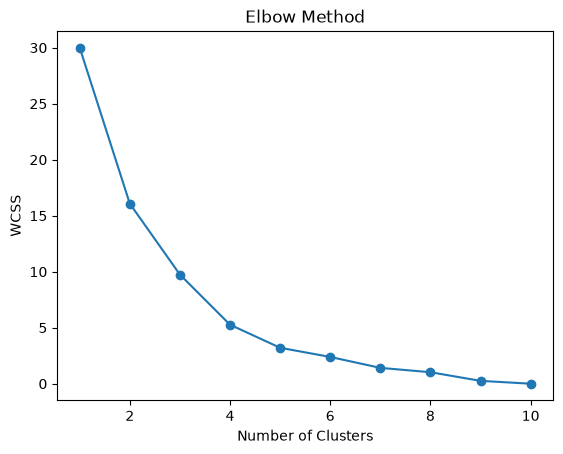

In [10]:
# Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
# K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

print("Cluster Labels:")
print(clusters)

Cluster Labels:
[0 0 0 0 0 1 2 1 2 1]


In [13]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


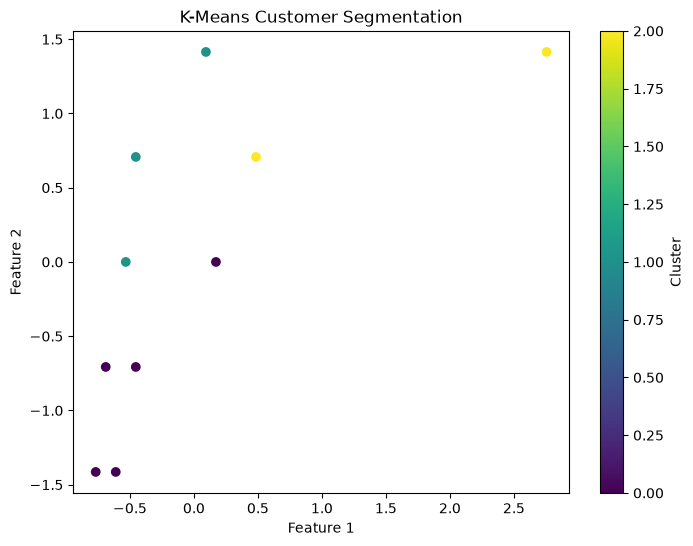

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("K-Means Customer Segmentation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster")
plt.show()

In [15]:
# Silhouette Score

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.26661791494598613


In [16]:
# PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (10, 3)
Reduced Shape: (10, 2)


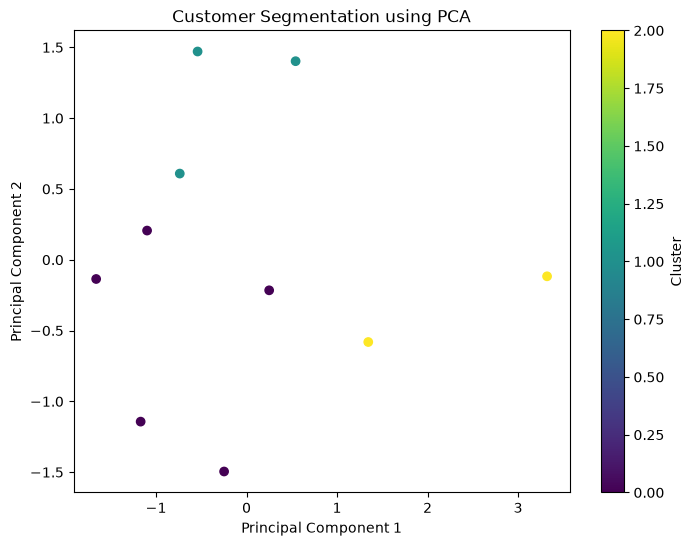

In [17]:
# PCA Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

In [18]:
# Cluster Centers

centers = kmeans.cluster_centers_

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[-0.46972579 -0.84852814 -0.0240289 ]
 [-0.297493    0.70710678  0.93912951]
 [ 1.62055396  1.06066017 -1.34862202]]


In [19]:
# Number of Customers in Each Cluster

print(df["Cluster"].value_counts())

Cluster
0    5
1    3
2    2
Name: count, dtype: int64


In [21]:
# Cluster Summary

numeric_df = df.select_dtypes(include=['number'])

cluster_summary = numeric_df.groupby(df["Cluster"]).mean()

print(cluster_summary)

         CustomerID   Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                              
0               3.0  22.8                15.8               48.600000
1               8.0  25.0                18.0               80.666667
2               8.0  49.5                18.5                4.500000


In [22]:
# PCA Explained Variance

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Preserved:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.64754628 0.28331166]
Total Variance Preserved:
0.9308579397418331


In [23]:
# Save Clustered Dataset

df.to_csv("customer_segments.csv", index=False)

print("Customer segmentation dataset saved successfully!")

Customer segmentation dataset saved successfully!


In [24]:
# Conclusion

print("""
========================================
 Customer Segmentation Engine Completed
========================================

✔ Dataset Loaded Successfully
✔ Data Preprocessing Completed
✔ Feature Scaling Applied
✔ Elbow Method Performed
✔ K-Means Clustering Applied
✔ Silhouette Score Evaluated
✔ PCA Dimensionality Reduction Applied
✔ Cluster Visualization Generated
✔ Cluster Profiles Created
✔ Clustered Dataset Saved Successfully

Project Completed Successfully!
""")


 Customer Segmentation Engine Completed

✔ Dataset Loaded Successfully
✔ Data Preprocessing Completed
✔ Feature Scaling Applied
✔ Elbow Method Performed
✔ K-Means Clustering Applied
✔ Silhouette Score Evaluated
✔ PCA Dimensionality Reduction Applied
✔ Cluster Visualization Generated
✔ Cluster Profiles Created
✔ Clustered Dataset Saved Successfully

Project Completed Successfully!

